In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/storesource/im-417-150/im_417_150.csv
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/173.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/379.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/248.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/94.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/236.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/340.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/48.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/350.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/314.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/227.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/238.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/61.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/377.png
/kaggle/input/datasets/storesource/im-417-150

Images found: 417

Successfully processed: 417

TABLE 1


,Mean,SD,Minimum,Median,Maximum
Nodes,10.909,6.208,0.000,10.000,30.000
Branches,4.899,4.416,0.000,4.000,27.000
Endpoints,6.010,4.631,0.000,5.000,28.000
Loops,1.986,2.531,0.000,1.000,15.000
Symmetry_X,0.479,0.227,0.027,0.503,0.897
Symmetry_Y,0.416,0.237,0.000,0.358,0.938
Aspect_Ratio,0.790,0.293,0.076,0.769,2.148
Convexity,0.378,0.095,0.163,0.366,0.972


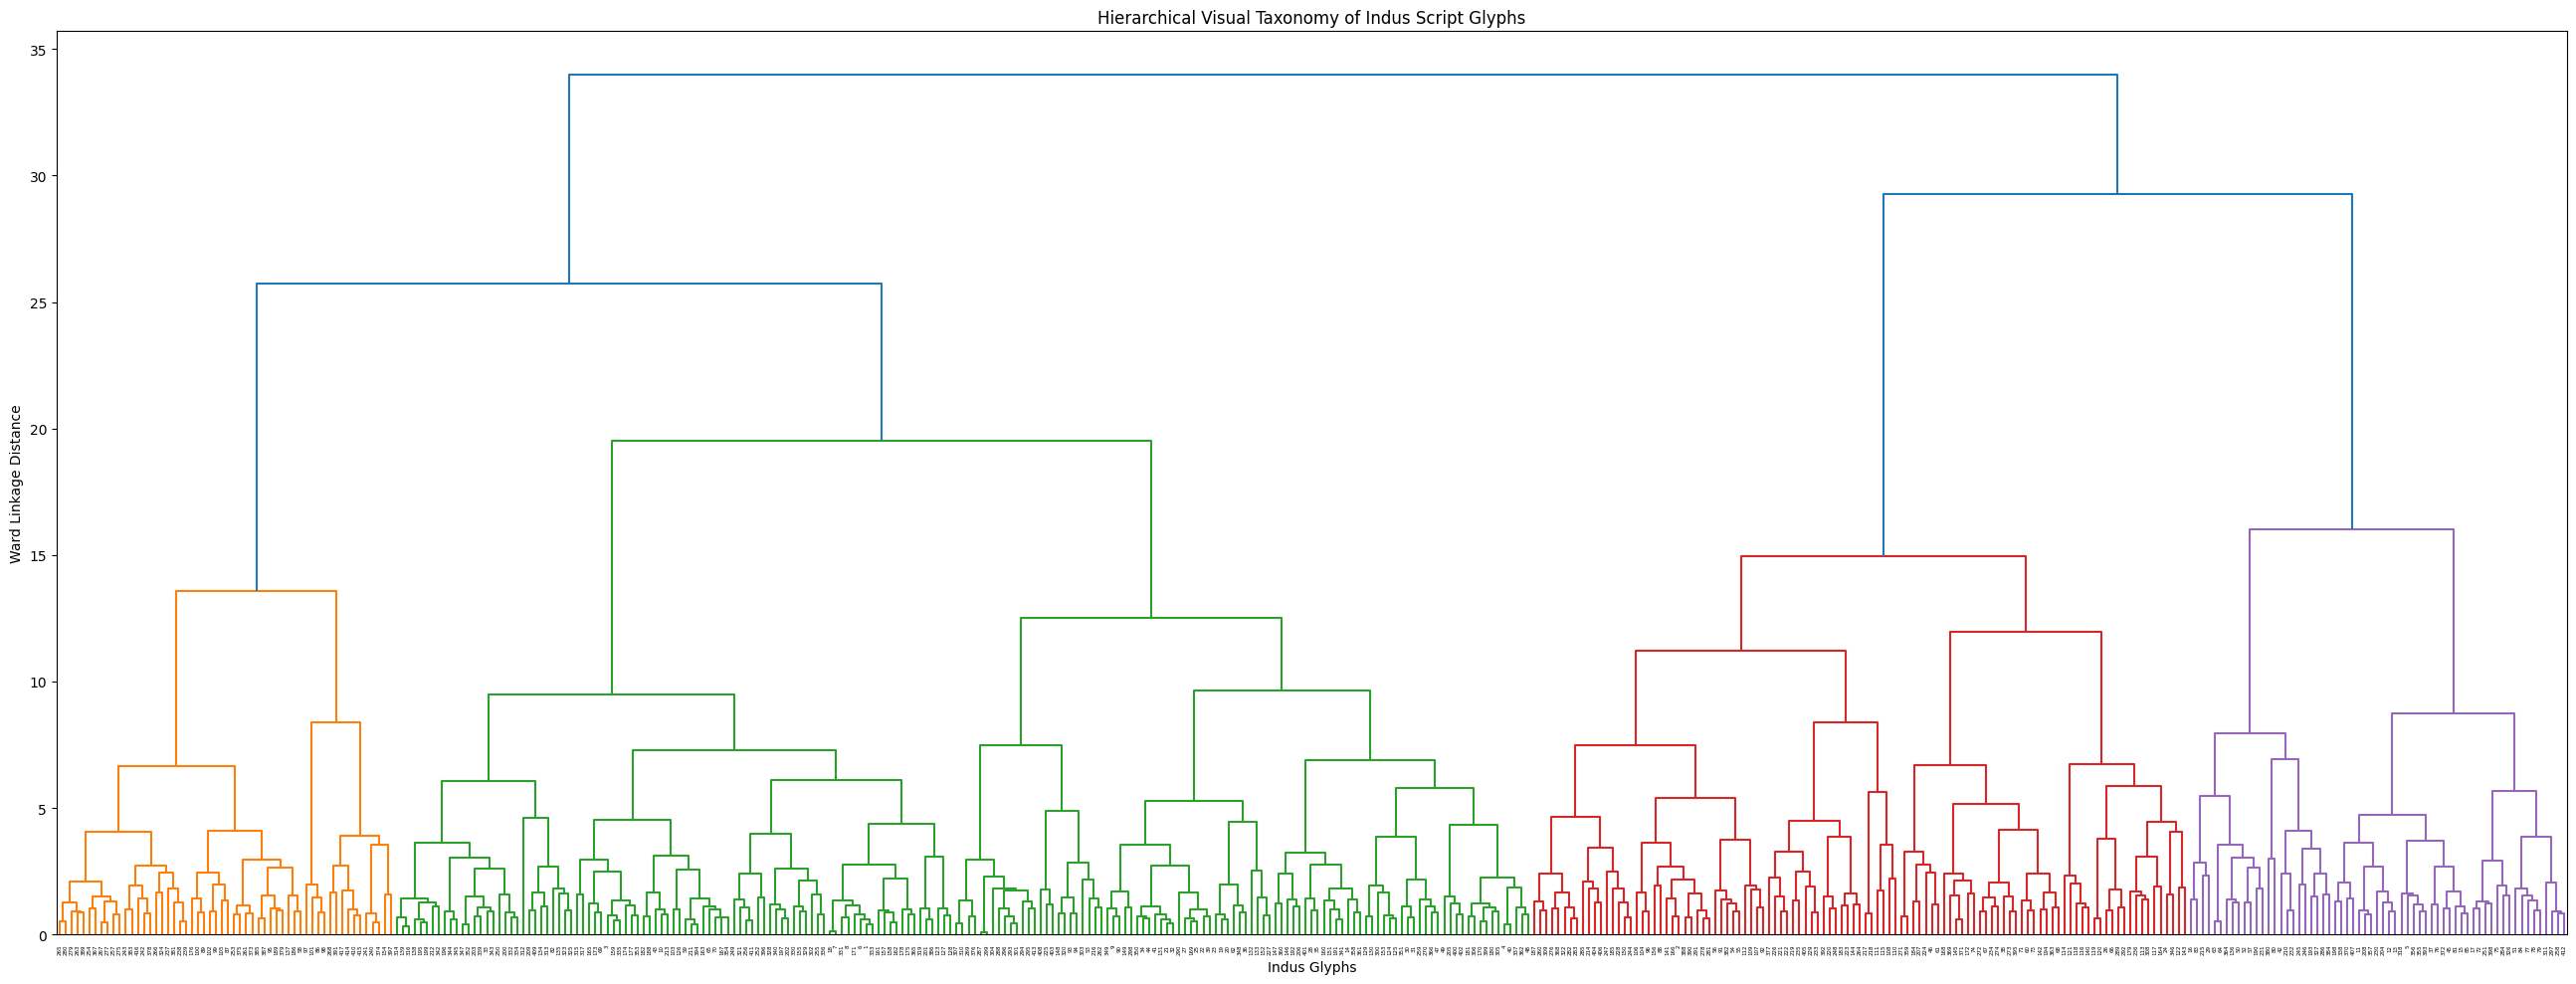


Optimal number of clusters: 130
Best silhouette score: 0.2225


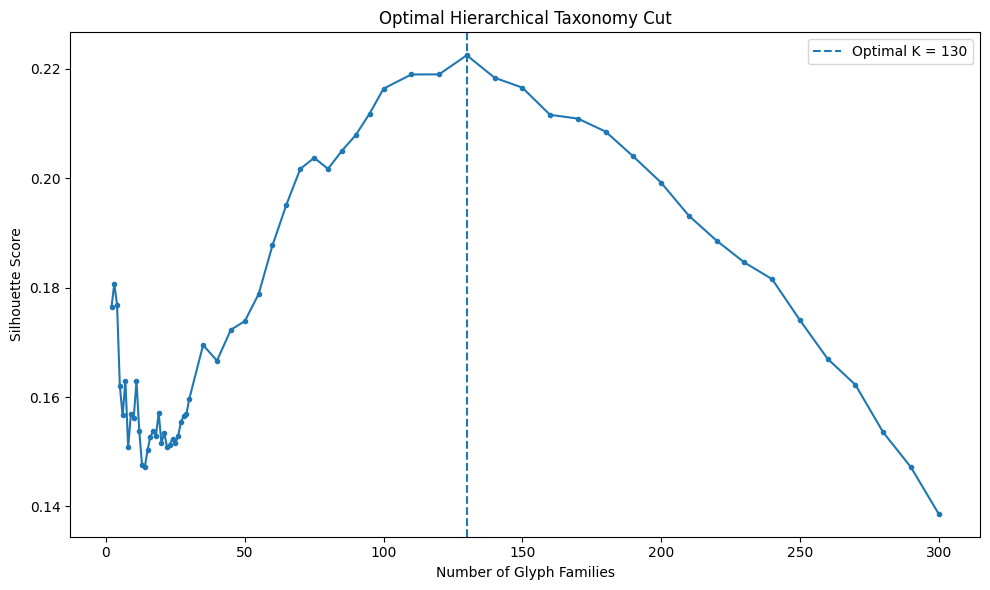


TABLE 2


,Metric,Value
0,Number of Glyphs,417.0000
1,Optimal Glyph Families,130.0000
2,Silhouette Score,0.2225
3,Davies-Bouldin Index,0.8991
4,Calinski-Harabasz Index,34.0592
5,Cophenetic Correlation,0.4329



TABLE 3


,Cluster,Cluster_Size,Master_Grapheme,Contains_Orphan_Candidate
33,34,8,333,False
15,16,8,138,False
27,28,8,59,False
40,41,8,296,False
46,47,7,32,False
55,56,7,151,False
47,48,6,169,False
1,2,6,277,False
24,25,6,335,False
17,18,6,339,False


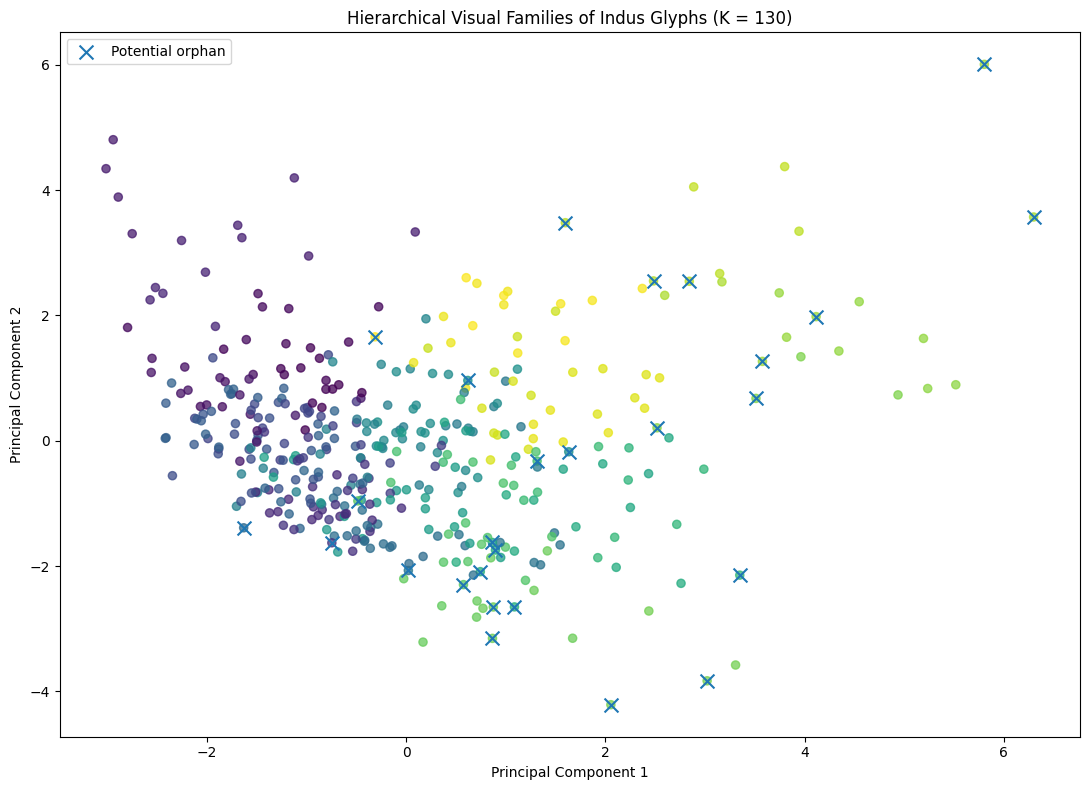


HIERARCHICAL TAXONOMY RESULTS
Glyphs analysed: 417
Optimal families: 130
Silhouette: 0.2225
Davies-Bouldin: 0.8991
Calinski-Harabasz: 34.0592
Cophenetic correlation: 0.4329
Potential orphan glyphs: 27
Master graphemes: 130

Files saved in: /kaggle/working/indus_hierarchical


In [2]:
# ============================================================
# HIERARCHICAL VISUAL TAXONOMY OF 417 INDUS GLYPHS
# Short Research-Paper Version
#
# Outputs:
# TABLE 1 - Structural feature descriptive statistics
# TABLE 2 - Hierarchical clustering validation metrics
# TABLE 3 - Master graphemes / orphan candidates
#
# FIGURE 1 - Hierarchical dendrogram
# FIGURE 2 - Silhouette optimization
# FIGURE 3 - PCA visualization
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import io, color, filters, morphology, measure
from skimage.morphology import skeletonize
from skimage.transform import resize

from scipy import ndimage
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)
from sklearn.decomposition import PCA


# ============================================================
# 2. SETTINGS
# ============================================================

INPUT_ROOT = "/kaggle/input"
OUTPUT_DIR = "/kaggle/working/indus_hierarchical"

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_EXTENSIONS = (
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
)

FEATURE_COLUMNS = [
    "Nodes",
    "Branches",
    "Endpoints",
    "Loops",
    "Symmetry_X",
    "Symmetry_Y",
    "Aspect_Ratio",
    "Convexity"
]


# ============================================================
# 3. FIND ALL GLYPH IMAGES
# ============================================================

image_paths = []

for root, dirs, files in os.walk(INPUT_ROOT):
    for file in files:
        if file.lower().endswith(IMAGE_EXTENSIONS):
            image_paths.append(
                os.path.join(root, file)
            )

image_paths = sorted(image_paths)

print("Images found:", len(image_paths))


# ============================================================
# 4. PREPROCESS GLYPH
# ============================================================

def preprocess(path):

    image = io.imread(path)

    if image.ndim == 3:
        image = color.rgb2gray(image)

    image = image.astype(float)

    if image.max() > 1:
        image /= 255.0

    threshold = filters.threshold_otsu(image)

    dark = image < threshold
    light = image > threshold

    # Select smaller foreground region
    binary = (
        dark if dark.mean() < light.mean()
        else light
    )

    binary = morphology.remove_small_objects(
        binary.astype(bool),
        min_size=5
    )

    coords = np.argwhere(binary)

    if len(coords) == 0:
        raise ValueError("No glyph foreground detected")

    ymin, xmin = coords.min(axis=0)
    ymax, xmax = coords.max(axis=0)

    crop = binary[
        ymin:ymax + 1,
        xmin:xmax + 1
    ]

    crop = np.pad(
        crop,
        5,
        constant_values=False
    )

    resized = resize(
        crop.astype(float),
        (128, 128),
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ) > 0.5

    return crop, resized


# ============================================================
# 5. STRUCTURAL FEATURES
# ============================================================

def neighbor_count(skeleton):

    kernel = np.ones((3, 3))
    kernel[1, 1] = 0

    return ndimage.convolve(
        skeleton.astype(int),
        kernel,
        mode="constant",
        cval=0
    )


def extract_features(path):

    binary, resized = preprocess(path)

    skeleton = skeletonize(binary)

    neighbors = neighbor_count(skeleton)

    endpoints_mask = (
        skeleton &
        (neighbors == 1)
    )

    branches_mask = (
        skeleton &
        (neighbors >= 3)
    )

    endpoints = measure.label(
        endpoints_mask,
        connectivity=2
    ).max()

    branches = measure.label(
        branches_mask,
        connectivity=2
    ).max()

    nodes = endpoints + branches

    components = measure.label(
        binary,
        connectivity=2
    ).max()

    euler = measure.euler_number(
        binary,
        connectivity=2
    )

    loops = max(
        0,
        components - euler
    )

    horizontal_flip = np.fliplr(
        resized
    )

    vertical_flip = np.flipud(
        resized
    )

    def jaccard(a, b):

        intersection = np.logical_and(
            a, b
        ).sum()

        union = np.logical_or(
            a, b
        ).sum()

        return (
            intersection / union
            if union != 0 else 1
        )

    symmetry_x = jaccard(
        resized,
        horizontal_flip
    )

    symmetry_y = jaccard(
        resized,
        vertical_flip
    )

    coords = np.argwhere(binary)

    ymin, xmin = coords.min(axis=0)
    ymax, xmax = coords.max(axis=0)

    height = ymax - ymin + 1
    width = xmax - xmin + 1

    aspect_ratio = width / height

    convex_hull = morphology.convex_hull_image(
        binary
    )

    convexity = (
        binary.sum() /
        convex_hull.sum()
    )

    return [
        nodes,
        branches,
        endpoints,
        loops,
        symmetry_x,
        symmetry_y,
        aspect_ratio,
        convexity
    ]


# ============================================================
# 6. EXTRACT FEATURES FOR ALL GLYPHS
# ============================================================

records = []

for i, path in enumerate(image_paths):

    try:

        features = extract_features(path)

        records.append(
            [
                os.path.splitext(
                    os.path.basename(path)
                )[0],
                path
            ] + features
        )

    except Exception as e:

        print(
            "Skipped:",
            path,
            str(e)
        )


df = pd.DataFrame(
    records,
    columns=[
        "Glyph_ID",
        "Image_Path"
    ] + FEATURE_COLUMNS
)

print("\nSuccessfully processed:", len(df))


# ============================================================
# TABLE 1
# DESCRIPTIVE STATISTICS OF 8 FEATURES
# ============================================================

table1 = (
    df[FEATURE_COLUMNS]
    .describe()
    .T[
        [
            "mean",
            "std",
            "min",
            "50%",
            "max"
        ]
    ]
)

table1.columns = [
    "Mean",
    "SD",
    "Minimum",
    "Median",
    "Maximum"
]

table1 = table1.round(3)

print("\nTABLE 1")
display(table1)

table1.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table1_Feature_Statistics.csv"
    )
)


# ============================================================
# 7. STANDARDIZE FEATURES
# ============================================================

X = df[
    FEATURE_COLUMNS
].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 8. WARD HIERARCHICAL CLUSTERING
# ============================================================

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)


# ============================================================
# FIGURE 1
# FULL DENDROGRAM
# ============================================================

plt.figure(
    figsize=(26, 10)
)

dendrogram(
    Z,
    labels=df[
        "Glyph_ID"
    ].astype(str).values,
    leaf_rotation=90,
    leaf_font_size=4
)

plt.xlabel(
    "Indus Glyphs"
)

plt.ylabel(
    "Ward Linkage Distance"
)

plt.title(
    "Hierarchical Visual Taxonomy of Indus Script Glyphs"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure1_Dendrogram.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. FIND OPTIMAL NUMBER OF CLUSTERS
# ============================================================
#
# Search up to 300 because your hypothesis concerns
# a potentially large master-grapheme inventory.
#
# ============================================================

max_clusters = min(
    300,
    len(df) - 1
)

cluster_range = list(
    range(2, 31)
)

cluster_range += list(
    range(35, 101, 5)
)

cluster_range += list(
    range(110, max_clusters + 1, 10)
)

results = []

for k in cluster_range:

    labels = fcluster(
        Z,
        k,
        criterion="maxclust"
    )

    actual_k = len(
        np.unique(labels)
    )

    if (
        actual_k > 1 and
        actual_k < len(df)
    ):

        score = silhouette_score(
            X_scaled,
            labels
        )

        results.append(
            [
                actual_k,
                score
            ]
        )


silhouette_df = pd.DataFrame(
    results,
    columns=[
        "Clusters",
        "Silhouette"
    ]
).drop_duplicates(
    "Clusters"
)


best_row = silhouette_df.loc[
    silhouette_df[
        "Silhouette"
    ].idxmax()
]

OPTIMAL_K = int(
    best_row["Clusters"]
)

print(
    "\nOptimal number of clusters:",
    OPTIMAL_K
)

print(
    "Best silhouette score:",
    round(
        best_row["Silhouette"],
        4
    )
)


# ============================================================
# FIGURE 2
# SILHOUETTE OPTIMIZATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    silhouette_df[
        "Clusters"
    ],
    silhouette_df[
        "Silhouette"
    ],
    marker="o",
    markersize=3
)

plt.axvline(
    OPTIMAL_K,
    linestyle="--",
    label=f"Optimal K = {OPTIMAL_K}"
)

plt.xlabel(
    "Number of Glyph Families"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Optimal Hierarchical Taxonomy Cut"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure2_Silhouette.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. FINAL CLUSTERS
# ============================================================

labels = fcluster(
    Z,
    OPTIMAL_K,
    criterion="maxclust"
)

df[
    "Cluster"
] = labels


# ============================================================
# 11. VALIDATION
# ============================================================

silhouette = silhouette_score(
    X_scaled,
    labels
)

davies_bouldin = davies_bouldin_score(
    X_scaled,
    labels
)

calinski = calinski_harabasz_score(
    X_scaled,
    labels
)

cophenetic_corr, _ = cophenet(
    Z,
    pdist(X_scaled)
)


# ============================================================
# TABLE 2
# CLUSTERING VALIDATION
# ============================================================

table2 = pd.DataFrame(
    {
        "Metric": [
            "Number of Glyphs",
            "Optimal Glyph Families",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Index",
            "Cophenetic Correlation"
        ],

        "Value": [
            len(df),
            OPTIMAL_K,
            round(
                silhouette,
                4
            ),
            round(
                davies_bouldin,
                4
            ),
            round(
                calinski,
                4
            ),
            round(
                cophenetic_corr,
                4
            )
        ]
    }
)

print("\nTABLE 2")
display(table2)

table2.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table2_Clustering_Validation.csv"
    ),
    index=False
)


# ============================================================
# 12. FIND MASTER GRAPHEME OF EACH FAMILY
# ============================================================
#
# Representative glyph = nearest glyph to cluster centroid
#
# ============================================================

master_records = []

for cluster_id in np.unique(
    labels
):

    indices = np.where(
        labels == cluster_id
    )[0]

    cluster_data = X_scaled[
        indices
    ]

    centroid = cluster_data.mean(
        axis=0
    )

    distances = np.linalg.norm(
        cluster_data - centroid,
        axis=1
    )

    local_index = np.argmin(
        distances
    )

    global_index = indices[
        local_index
    ]

    master_records.append(
        [
            cluster_id,
            len(indices),
            df.iloc[
                global_index
            ]["Glyph_ID"]
        ]
    )


masters = pd.DataFrame(
    master_records,
    columns=[
        "Cluster",
        "Cluster_Size",
        "Master_Grapheme"
    ]
)


# ============================================================
# 13. IDENTIFY ORPHAN GLYPHS
# ============================================================

cluster_sizes = (
    df["Cluster"]
    .value_counts()
)

df[
    "Cluster_Size"
] = df[
    "Cluster"
].map(
    cluster_sizes
)


# Nearest neighbour distance
distance_matrix = pairwise_distances(
    X_scaled
)

np.fill_diagonal(
    distance_matrix,
    np.inf
)

nearest_distance = distance_matrix.min(
    axis=1
)

df[
    "Nearest_Distance"
] = nearest_distance

threshold = np.percentile(
    nearest_distance,
    95
)

df[
    "Potential_Orphan"
] = (
    (df["Cluster_Size"] == 1)
    |
    (
        df[
            "Nearest_Distance"
        ] >= threshold
    )
)


orphans = df[
    df[
        "Potential_Orphan"
    ]
].sort_values(
    "Nearest_Distance",
    ascending=False
)


# ============================================================
# TABLE 3
# MASTER GRAPHEMES + ORPHAN STATUS
# ============================================================

table3 = masters.copy()

orphan_clusters = set(
    orphans[
        "Cluster"
    ]
)

table3[
    "Contains_Orphan_Candidate"
] = table3[
    "Cluster"
].isin(
    orphan_clusters
)

table3 = table3.sort_values(
    "Cluster_Size",
    ascending=False
)

print("\nTABLE 3")
display(
    table3.head(30)
)

table3.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Table3_Master_Graphemes.csv"
    ),
    index=False
)

orphans[
    [
        "Glyph_ID",
        "Cluster",
        "Cluster_Size",
        "Nearest_Distance"
    ]
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Orphan_Glyphs.csv"
    ),
    index=False
)


# ============================================================
# 14. PCA VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

df[
    "PCA1"
] = X_pca[:, 0]

df[
    "PCA2"
] = X_pca[:, 1]


# ============================================================
# FIGURE 3
# PCA MAP OF HIERARCHICAL FAMILIES
# ============================================================

plt.figure(
    figsize=(11, 8)
)

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    s=35,
    alpha=0.75
)

# Mark orphan candidates
orphan_points = df[
    df[
        "Potential_Orphan"
    ]
]

plt.scatter(
    orphan_points[
        "PCA1"
    ],
    orphan_points[
        "PCA2"
    ],
    marker="x",
    s=100,
    label="Potential orphan"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    f"Hierarchical Visual Families of Indus Glyphs "
    f"(K = {OPTIMAL_K})"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Figure3_PCA_Glyph_Families.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. SAVE COMPLETE GLYPH DATA
# ============================================================

df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Hierarchical_Glyph_Results.csv"
    ),
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)

print(
    "HIERARCHICAL TAXONOMY RESULTS"
)

print("=" * 60)

print(
    "Glyphs analysed:",
    len(df)
)

print(
    "Optimal families:",
    OPTIMAL_K
)

print(
    "Silhouette:",
    round(
        silhouette,
        4
    )
)

print(
    "Davies-Bouldin:",
    round(
        davies_bouldin,
        4
    )
)

print(
    "Calinski-Harabasz:",
    round(
        calinski,
        4
    )
)

print(
    "Cophenetic correlation:",
    round(
        cophenetic_corr,
        4
    )
)

print(
    "Potential orphan glyphs:",
    len(orphans)
)

print(
    "Master graphemes:",
    len(masters)
)

print("=" * 60)

print(
    "\nFiles saved in:",
    OUTPUT_DIR
)

In [3]:
# ==================================================================================================
# INDUSGPT — COMPLETE KAGGLE PIPELINE FROM RAW IM-417 PNG IMAGES
# ==================================================================================================
#
# Input:
# /kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/*.png
#
# Pipeline:
#
# 417 PNG Glyphs
#      ↓
# Image Preprocessing
#      ↓
# Morphometric Feature Extraction
#      ↓
# Structural Similarity
#      ↓
# Glyph Complexity Index
#      ↓
# Distinctiveness Analysis
#      ↓
# Nearest-Neighbour Retrieval
#      ↓
# Natural-Language Knowledge Base
#      ↓
# Semantic Retrieval
#      ↓
# Hybrid Retrieval
#      ↓
# IndusGPT
#
# ==================================================================================================


# ==================================================================================================
# 1. INSTALL PACKAGES
# ==================================================================================================

!pip install -q sentence-transformers openai opencv-python-headless


# ==================================================================================================
# 2. IMPORT LIBRARIES
# ==================================================================================================

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INPUT_DIR = Path(
    "/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG"
)

OUTPUT_DIR = Path(
    "/kaggle/working"
)

print("=" * 90)
print("INDUSGPT")
print("Raw IM-417 Image → Morphometric Knowledge Base")
print("=" * 90)


# ==================================================================================================
# 3. FIND ALL PNG IMAGES
# ==================================================================================================

image_files = sorted(
    list(INPUT_DIR.glob("*.png")),
    key=lambda p: int(p.stem)
)

print("\nImages found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError(
        f"No PNG files found in {INPUT_DIR}"
    )

print("\nFirst 10 images:")

for path in image_files[:10]:
    print(path)


# ==================================================================================================
# 4. IMAGE PREPROCESSING FUNCTION
# ==================================================================================================

def preprocess_image(image_path):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read {image_path}"
        )

    # Gaussian smoothing
    blurred = cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )

    # Automatic binary thresholding
    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Ensure symbol is white foreground
    # and background is black
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    # Remove small noise
    kernel = np.ones(
        (2, 2),
        np.uint8
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    return image, binary


# ==================================================================================================
# 5. FEATURE EXTRACTION FUNCTION
# ==================================================================================================

def extract_features(image_path):

    original, binary = preprocess_image(
        image_path
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:

        return None


    # Combine contour information
    contour = max(
        contours,
        key=cv2.contourArea
    )


    # ----------------------------------------------------------------------------------------------
    # GEOMETRIC FEATURES
    # ----------------------------------------------------------------------------------------------

    area = cv2.contourArea(
        contour
    )

    perimeter = cv2.arcLength(
        contour,
        True
    )


    x, y, width, height = cv2.boundingRect(
        contour
    )


    aspect_ratio = (
        width / height
        if height != 0
        else 0
    )


    bounding_area = (
        width * height
    )


    extent = (
        area / bounding_area
        if bounding_area > 0
        else 0
    )


    hull = cv2.convexHull(
        contour
    )

    hull_area = cv2.contourArea(
        hull
    )


    solidity = (
        area / hull_area
        if hull_area > 0
        else 0
    )


    circularity = (
        (4 * np.pi * area)
        /
        (perimeter ** 2)
        if perimeter > 0
        else 0
    )


    # ----------------------------------------------------------------------------------------------
    # MOMENTS / CENTROID
    # ----------------------------------------------------------------------------------------------

    moments = cv2.moments(
        contour
    )


    if moments["m00"] != 0:

        center_x = (
            moments["m10"]
            /
            moments["m00"]
        )

        center_y = (
            moments["m01"]
            /
            moments["m00"]
        )

    else:

        center_x = 0
        center_y = 0


    # ----------------------------------------------------------------------------------------------
    # ECCENTRICITY AND ORIENTATION
    # ----------------------------------------------------------------------------------------------

    eccentricity = 0
    orientation = 0


    if len(contour) >= 5:

        ellipse = cv2.fitEllipse(
            contour
        )

        (cx, cy), (
            major_axis,
            minor_axis
        ), angle = ellipse


        major = max(
            major_axis,
            minor_axis
        )

        minor = min(
            major_axis,
            minor_axis
        )


        if major > 0:

            eccentricity = np.sqrt(
                max(
                    0,
                    1 -
                    (
                        minor ** 2
                        /
                        major ** 2
                    )
                )
            )


        orientation = angle


    # ----------------------------------------------------------------------------------------------
    # PIXEL / INK FEATURES
    # ----------------------------------------------------------------------------------------------

    foreground_pixels = original[
        binary > 0
    ]


    if len(
        foreground_pixels
    ) > 0:

        mean_intensity = float(
            np.mean(
                foreground_pixels
            )
        )

        std_intensity = float(
            np.std(
                foreground_pixels
            )
        )

        median_intensity = float(
            np.median(
                foreground_pixels
            )
        )

        min_intensity = float(
            np.min(
                foreground_pixels
            )
        )

        max_intensity = float(
            np.max(
                foreground_pixels
            )
        )

    else:

        mean_intensity = 0
        std_intensity = 0
        median_intensity = 0
        min_intensity = 0
        max_intensity = 0


    # Ink density
    density = (
        np.count_nonzero(
            binary
        )
        /
        binary.size
    )


    # ----------------------------------------------------------------------------------------------
    # HU MOMENTS
    # ----------------------------------------------------------------------------------------------

    hu = cv2.HuMoments(
        moments
    ).flatten()


    # Log-transform Hu moments for stability
    hu_log = []

    for value in hu:

        if value == 0:

            hu_log.append(
                0.0
            )

        else:

            hu_log.append(
                -np.sign(value)
                *
                np.log10(
                    abs(value)
                )
            )


    symbol_number = int(
        image_path.stem
    )


    return {

        "symbol_id":
            symbol_number,

        "IndusGPT_ID":
            f"S{symbol_number:03d}",

        "filename":
            image_path.name,

        "area":
            float(area),

        "perimeter":
            float(perimeter),

        "solidity":
            float(solidity),

        "aspect_ratio":
            float(aspect_ratio),

        "extent":
            float(extent),

        "circularity":
            float(circularity),

        "center_x":
            float(center_x),

        "center_y":
            float(center_y),

        "eccentricity":
            float(eccentricity),

        "orientation":
            float(orientation),

        "mean_intensity":
            mean_intensity,

        "std_intensity":
            std_intensity,

        "median_intensity":
            median_intensity,

        "min_intensity":
            min_intensity,

        "max_intensity":
            max_intensity,

        "width":
            int(width),

        "height":
            int(height),

        "density":
            float(density),

        "hu_1":
            float(
                hu_log[0]
            ),

        "hu_2":
            float(
                hu_log[1]
            ),

        "hu_3":
            float(
                hu_log[2]
            ),

        "hu_4":
            float(
                hu_log[3]
            ),

        "hu_5":
            float(
                hu_log[4]
            ),

        "hu_6":
            float(
                hu_log[5]
            ),

        "hu_7":
            float(
                hu_log[6]
            )
    }


# ==================================================================================================
# 6. EXTRACT FEATURES FROM ALL 417 SYMBOLS
# ==================================================================================================

feature_records = []

failed_images = []


for path in image_files:

    try:

        record = extract_features(
            path
        )

        if record is not None:

            feature_records.append(
                record
            )

        else:

            failed_images.append(
                str(path)
            )

    except Exception as e:

        print(
            "Failed:",
            path.name,
            "|",
            e
        )

        failed_images.append(
            str(path)
        )


features_df = pd.DataFrame(
    feature_records
)


print("\nSuccessfully processed:", len(features_df))
print("Failed images:", len(failed_images))


display(
    features_df.head()
)


# ==================================================================================================
# 7. SAVE EXTRACTED FEATURES
# ==================================================================================================

feature_output_path = (
    OUTPUT_DIR /
    "symbol_features.csv"
)


features_df.to_csv(
    feature_output_path,
    index=False
)


print(
    "\nFeature dataset saved to:",
    feature_output_path
)


# ==================================================================================================
# 8. FEATURE LIST
# ==================================================================================================

feature_columns = [

    "area",
    "perimeter",
    "solidity",
    "aspect_ratio",
    "extent",
    "circularity",

    "center_x",
    "center_y",

    "eccentricity",
    "orientation",

    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "min_intensity",
    "max_intensity",

    "width",
    "height",

    "density",

    "hu_1",
    "hu_2",
    "hu_3",
    "hu_4",
    "hu_5",
    "hu_6",
    "hu_7"
]


print(
    "\nFeatures extracted:",
    len(feature_columns)
)


# ==================================================================================================
# 9. DESCRIPTIVE STATISTICS
# ==================================================================================================

X = features_df[
    feature_columns
].copy()


X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


for column in feature_columns:

    X[column] = X[
        column
    ].fillna(
        X[column].median()
    )


descriptive_stats = (

    X.describe()
    .T
    .reset_index()

)


descriptive_stats = descriptive_stats.rename(
    columns={
        "index":
        "feature"
    }
)


display(
    descriptive_stats
)


descriptive_stats.to_csv(

    OUTPUT_DIR /
    "indusgpt_descriptive_statistics.csv",

    index=False
)


# ==================================================================================================
# 10. ROBUST NORMALIZATION
# ==================================================================================================

scaler = RobustScaler()


X_scaled = scaler.fit_transform(
    X
)


X_scaled_df = pd.DataFrame(

    X_scaled,

    columns=
        feature_columns,

    index=
        features_df.index
)


print(
    "\nNormalized feature matrix:",
    X_scaled.shape
)


# ==================================================================================================
# 11. FEATURE WEIGHTS FOR MORPHOLOGICAL RETRIEVAL
# ==================================================================================================

feature_weights = {}


for feature in feature_columns:

    # Strong shape descriptors
    if feature in [

        "area",
        "perimeter",
        "solidity",
        "aspect_ratio",
        "extent",
        "circularity",
        "eccentricity",
        "width",
        "height",
        "density"

    ]:

        feature_weights[
            feature
        ] = 1.0


    # Hu moments capture global invariant geometry
    elif feature.startswith(
        "hu_"
    ):

        feature_weights[
            feature
        ] = 1.0


    # Position/orientation lower weight
    elif feature in [

        "center_x",
        "center_y",
        "orientation"

    ]:

        feature_weights[
            feature
        ] = 0.50


    # Intensity lower weight
    elif "intensity" in feature:

        feature_weights[
            feature
        ] = 0.30


weight_vector = np.array(

    [
        feature_weights[
            f
        ]

        for f
        in feature_columns
    ]
)


X_weighted = (
    X_scaled
    *
    weight_vector
)


weights_df = pd.DataFrame(
    {
        "feature":
            feature_columns,

        "weight":
            weight_vector
    }
)


display(
    weights_df
)


# ==================================================================================================
# 12. STRUCTURAL SIMILARITY MATRIX
# ==================================================================================================

structural_similarity_matrix = cosine_similarity(
    X_weighted
)


morphological_distance_matrix = pairwise_distances(
    X_weighted,
    metric="euclidean"
)


print(
    "\nSimilarity matrix:",
    structural_similarity_matrix.shape
)


# ==================================================================================================
# 13. SYMBOL LOOKUP
# ==================================================================================================

def get_symbol_index(
    symbol
):

    symbol = str(
        symbol
    ).strip()


    # S001 style
    digits = re.findall(
        r"\d+",
        symbol
    )


    if digits:

        number = int(
            digits[0]
        )


        matches = features_df.index[
            features_df[
                "symbol_id"
            ]
            ==
            number
        ]


        if len(
            matches
        ) > 0:

            return matches[
                0
            ]


    return None


# ==================================================================================================
# 14. FIND STRUCTURALLY SIMILAR SYMBOLS
# ==================================================================================================

def find_similar_symbols(
    symbol,
    top_k=10
):

    idx = get_symbol_index(
        symbol
    )


    if idx is None:

        return pd.DataFrame()


    similarities = structural_similarity_matrix[
        idx
    ]


    distances = morphological_distance_matrix[
        idx
    ]


    ranked = np.argsort(
        similarities
    )[::-1]


    ranked = [

        i
        for i in ranked
        if i != idx

    ][
        :top_k
    ]


    results = features_df.loc[
        ranked,
        [
            "symbol_id",
            "IndusGPT_ID",
            "area",
            "perimeter",
            "aspect_ratio",
            "circularity",
            "eccentricity",
            "density"
        ]
    ].copy()


    results.insert(

        2,

        "structural_similarity",

        [
            similarities[
                i
            ]

            for i
            in ranked
        ]
    )


    results.insert(

        3,

        "morphological_distance",

        [
            distances[
                i
            ]

            for i
            in ranked
        ]
    )


    return results.reset_index(
        drop=True
    )


print(
    "\nExample nearest-neighbour retrieval:"
)


display(
    find_similar_symbols(
        "S001",
        top_k=10
    )
)


# ==================================================================================================
# 15. EXPLAIN WHY TWO SYMBOLS DIFFER
# ==================================================================================================

def compare_symbols(
    symbol_a,
    symbol_b
):

    idx_a = get_symbol_index(
        symbol_a
    )

    idx_b = get_symbol_index(
        symbol_b
    )


    if idx_a is None or idx_b is None:

        return None


    differences = np.abs(

        X_weighted[
            idx_a
        ]

        -

        X_weighted[
            idx_b
        ]

    )


    comparison = pd.DataFrame(
        {
            "feature":
                feature_columns,

            symbol_a:
                X.loc[
                    idx_a,
                    feature_columns
                ].values,

            symbol_b:
                X.loc[
                    idx_b,
                    feature_columns
                ].values,

            "standardized_difference":
                differences
        }
    )


    comparison = comparison.sort_values(

        "standardized_difference",

        ascending=False

    )


    similarity = structural_similarity_matrix[
        idx_a,
        idx_b
    ]


    print(
        f"Structural similarity = "
        f"{similarity:.4f}"
    )


    return comparison.reset_index(
        drop=True
    )


display(
    compare_symbols(
        "S001",
        "S002"
    ).head(10)
)


# ==================================================================================================
# 16. GLYPH COMPLEXITY INDEX
# ==================================================================================================
#
# This is GRAPHICAL / MORPHOMETRIC complexity.
# It does NOT imply linguistic complexity.
#
# Components:
# - contour perimeter
# - area
# - density
# - eccentricity
# - aspect ratio
# - Hu-moment deviation
#
# ==================================================================================================

complexity_features = [

    "area",
    "perimeter",
    "density",
    "eccentricity",
    "aspect_ratio"
]


complexity_values = np.zeros(
    len(features_df)
)


for feature in complexity_features:

    complexity_values += np.abs(

        X_scaled_df[
            feature
        ].values

    )


hu_columns = [

    f"hu_{i}"
    for i in range(
        1,
        8
    )
]


hu_complexity = np.mean(

    np.abs(
        X_scaled_df[
            hu_columns
        ].values
    ),

    axis=1
)


complexity_values += hu_complexity


complexity_values /= (
    len(
        complexity_features
    )
    +
    1
)


# Normalize 0–100

min_gci = complexity_values.min()

max_gci = complexity_values.max()


features_df[
    "Glyph_Complexity_Index"
] = (

    (
        complexity_values
        -
        min_gci
    )

    /

    (
        max_gci
        -
        min_gci
        +
        1e-12
    )

) * 100


# Corpus-relative classes

q25 = features_df[
    "Glyph_Complexity_Index"
].quantile(
    0.25
)

q75 = features_df[
    "Glyph_Complexity_Index"
].quantile(
    0.75
)


def classify_complexity(
    value
):

    if value <= q25:

        return "Low"

    elif value >= q75:

        return "High"

    else:

        return "Moderate"


features_df[
    "Complexity_Level"
] = features_df[
    "Glyph_Complexity_Index"
].apply(
    classify_complexity
)


print(
    "\nMost morphometrically complex glyphs:"
)


display(

    features_df[
        [
            "IndusGPT_ID",
            "Glyph_Complexity_Index",
            "Complexity_Level",
            "area",
            "perimeter",
            "density"
        ]
    ]

    .sort_values(

        "Glyph_Complexity_Index",

        ascending=False

    )

    .head(20)

)


# ==================================================================================================
# 17. MORPHOLOGICAL DISTINCTIVENESS
# ==================================================================================================

mean_similarity = (

    (
        structural_similarity_matrix.sum(
            axis=1
        )
        -
        1
    )

    /

    (
        len(
            features_df
        )
        -
        1
    )
)


features_df[
    "Mean_Corpus_Similarity"
] = mean_similarity


features_df[
    "Distinctiveness_Score"
] = (
    1 -
    mean_similarity
)


print(
    "\nMost morphologically distinctive glyphs:"
)


display(

    features_df[
        [
            "IndusGPT_ID",
            "Distinctiveness_Score",
            "Glyph_Complexity_Index"
        ]
    ]

    .sort_values(

        "Distinctiveness_Score",

        ascending=False

    )

    .head(20)

)


# ==================================================================================================
# 18. LOCAL STRUCTURAL SIMILARITY
# ==================================================================================================

TOP_K = 5

local_scores = []


for idx in range(
    len(features_df)
):

    scores = structural_similarity_matrix[
        idx
    ].copy()


    scores[
        idx
    ] = -np.inf


    nearest = np.sort(
        scores
    )[::-1][
        :TOP_K
    ]


    local_scores.append(
        np.mean(
            nearest
        )
    )


features_df[
    "Local_Similarity_Score"
] = local_scores


# ==================================================================================================
# 19. CORPUS PERCENTILE DESCRIPTION
# ==================================================================================================

def percentile_rank(
    column,
    value
):

    return (

        features_df[
            column
        ]
        .le(
            value
        )
        .mean()

        *
        100
    )


def verbal_level(
    percentile
):

    if percentile >= 80:
        return "very high"

    elif percentile >= 60:
        return "high"

    elif percentile >= 40:
        return "moderate"

    elif percentile >= 20:
        return "low"

    else:
        return "very low"


# ==================================================================================================
# 20. CREATE STRUCTURAL DESCRIPTION FOR EACH GLYPH
# ==================================================================================================

def make_structural_profile(
    idx
):

    row = features_df.loc[
        idx
    ]


    selected = [

        "area",
        "perimeter",
        "aspect_ratio",
        "solidity",
        "extent",
        "circularity",
        "eccentricity",
        "density"

    ]


    descriptions = []


    for feature in selected:

        value = row[
            feature
        ]


        percentile = percentile_rank(

            feature,

            value

        )


        level = verbal_level(
            percentile
        )


        descriptions.append(

            f"{feature}={value:.4f} "
            f"({level}; "
            f"{percentile:.1f} percentile)"

        )


    descriptions.append(

        f"Glyph Complexity Index="
        f"{row['Glyph_Complexity_Index']:.2f}/100 "
        f"({row['Complexity_Level']})"

    )


    descriptions.append(

        f"Distinctiveness Score="
        f"{row['Distinctiveness_Score']:.4f}"

    )


    return "; ".join(
        descriptions
    )


features_df[
    "Structural_Profile"
] = [

    make_structural_profile(
        idx
    )

    for idx
    in features_df.index
]


print(
    "\nExample structural profile:"
)

print(
    features_df.iloc[
        0
    ][
        "Structural_Profile"
    ]
)


# ==================================================================================================
# 21. CREATE KNOWLEDGE TEXT
# ==================================================================================================

def create_knowledge_text(
    idx
):

    row = features_df.loc[
        idx
    ]


    symbol = row[
        "IndusGPT_ID"
    ]


    neighbours = find_similar_symbols(

        symbol,

        top_k=3

    )


    neighbour_text = []


    for _, nrow in neighbours.iterrows():

        neighbour_text.append(

            f"{nrow['IndusGPT_ID']} "
            f"(similarity="
            f"{nrow['structural_similarity']:.4f})"

        )


    text = (

        f"Indus symbol {symbol}. "

        f"This glyph is part of the IM-417 digital heritage corpus. "

        f"Morphometric profile: "
        f"{row['Structural_Profile']}. "

        f"Nearest morphometric neighbours are "
        f"{', '.join(neighbour_text)}. "

        f"The reported similarities describe graphical structure only "
        f"and do not establish linguistic meaning or equivalence."

    )


    return text


features_df[
    "Knowledge_Text"
] = [

    create_knowledge_text(
        idx
    )

    for idx
    in features_df.index
]


print(
    "\nExample knowledge record:\n"
)

print(
    features_df.iloc[
        0
    ][
        "Knowledge_Text"
    ]
)


# ==================================================================================================
# 22. SAVE AUGMENTED DATASET
# ==================================================================================================

features_df.to_csv(

    OUTPUT_DIR /
    "indusgpt_augmented_IM417.csv",

    index=False
)


# ==================================================================================================
# 23. CREATE JSON KNOWLEDGE BASE
# ==================================================================================================

knowledge_base = []


for _, row in features_df.iterrows():

    entry = {

        "symbol_id":
            row[
                "IndusGPT_ID"
            ],

        "image_file":
            row[
                "filename"
            ],

        "complexity_index":
            float(
                row[
                    "Glyph_Complexity_Index"
                ]
            ),

        "complexity_level":
            row[
                "Complexity_Level"
            ],

        "distinctiveness_score":
            float(
                row[
                    "Distinctiveness_Score"
                ]
            ),

        "local_similarity":
            float(
                row[
                    "Local_Similarity_Score"
                ]
            ),

        "morphometric_features":
            {

                feature:
                    float(
                        row[
                            feature
                        ]
                    )

                for feature
                in feature_columns

            },

        "structural_profile":
            row[
                "Structural_Profile"
            ],

        "knowledge_text":
            row[
                "Knowledge_Text"
            ]
    }


    knowledge_base.append(
        entry
    )


with open(

    OUTPUT_DIR /
    "indusgpt_knowledge_base.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        knowledge_base,

        f,

        indent=2,

        ensure_ascii=False

    )


print(
    "\nKnowledge base created:",
    len(
        knowledge_base
    ),
    "records"
)


# ==================================================================================================
# 24. SEMANTIC EMBEDDING MODEL
# ==================================================================================================
#
# Kaggle Internet must be enabled for first download.
#
# ==================================================================================================

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


documents = features_df[
    "Knowledge_Text"
].tolist()


document_embeddings = embedding_model.encode(

    documents,

    normalize_embeddings=True,

    show_progress_bar=True

)


print(
    "\nDocument embeddings:",
    document_embeddings.shape
)


# ==================================================================================================
# 25. SEMANTIC RETRIEVAL
# ==================================================================================================

def semantic_search(
    query,
    top_k=10
):

    query_embedding = embedding_model.encode(

        [query],

        normalize_embeddings=True

    )


    scores = cosine_similarity(

        query_embedding,

        document_embeddings

    )[0]


    ranked = np.argsort(
        scores
    )[::-1][
        :top_k
    ]


    results = []


    for idx in ranked:

        results.append(
            {

                "index":
                    int(
                        idx
                    ),

                "symbol_id":
                    features_df.iloc[
                        idx
                    ][
                        "IndusGPT_ID"
                    ],

                "semantic_score":
                    float(
                        scores[
                            idx
                        ]
                    ),

                "evidence":
                    features_df.iloc[
                        idx
                    ][
                        "Knowledge_Text"
                    ]
            }
        )


    return results


# ==================================================================================================
# 26. EXTRACT SYMBOL IDS FROM QUERY
# ==================================================================================================

def extract_symbol_ids(
    query
):

    matches = re.findall(

        r"\b[Ss](\d+)\b",

        query

    )


    output = []


    for match in matches:

        number = int(
            match
        )


        if number in features_df[
            "symbol_id"
        ].values:

            output.append(
                f"S{number:03d}"
            )


    return list(
        dict.fromkeys(
            output
        )
    )


# ==================================================================================================
# 27. HYBRID RETRIEVAL
# ==================================================================================================

def hybrid_retrieve(
    query,
    top_k=7,
    neighbour_k=5
):

    semantic_results = semantic_search(

        query,

        top_k=max(
            10,
            top_k * 2
        )
    )


    candidates = {}


    # ----------------------------------------------------------------------------------------------
    # Semantic evidence
    # ----------------------------------------------------------------------------------------------

    for item in semantic_results:

        idx = item[
            "index"
        ]


        candidates[
            idx
        ] = {

            "semantic":
                item[
                    "semantic_score"
                ],

            "structural":
                0.0,

            "exact":
                0.0
        }


    # ----------------------------------------------------------------------------------------------
    # Explicit requested symbols
    # ----------------------------------------------------------------------------------------------

    mentioned = extract_symbol_ids(
        query
    )


    for symbol in mentioned:

        idx = get_symbol_index(
            symbol
        )


        if idx is None:
            continue


        if idx not in candidates:

            candidates[
                idx
            ] = {

                "semantic":
                    0,

                "structural":
                    0,

                "exact":
                    0
            }


        candidates[
            idx
        ][
            "exact"
        ] = 1.0


        nearest = np.argsort(

            structural_similarity_matrix[
                idx
            ]

        )[::-1]


        nearest = [

            i
            for i in nearest
            if i != idx

        ][
            :neighbour_k
        ]


        for neighbour in nearest:

            if neighbour not in candidates:

                candidates[
                    neighbour
                ] = {

                    "semantic":
                        0,

                    "structural":
                        0,

                    "exact":
                        0
                }


            candidates[
                neighbour
            ][
                "structural"
            ] = max(

                candidates[
                    neighbour
                ][
                    "structural"
                ],

                float(

                    structural_similarity_matrix[
                        idx,
                        neighbour
                    ]

                )
            )


    # ----------------------------------------------------------------------------------------------
    # Score fusion
    # ----------------------------------------------------------------------------------------------

    ranked_results = []


    for idx, scores in candidates.items():

        semantic = max(
            0,
            scores[
                "semantic"
            ]
        )


        structural = max(
            0,
            scores[
                "structural"
            ]
        )


        exact = scores[
            "exact"
        ]


        hybrid_score = (

            0.55
            *
            semantic

            +

            0.30
            *
            structural

            +

            0.15
            *
            exact

        )


        if exact == 1:

            hybrid_score += 1


        ranked_results.append(
            {

                "index":
                    idx,

                "symbol_id":
                    features_df.loc[
                        idx,
                        "IndusGPT_ID"
                    ],

                "semantic_score":
                    semantic,

                "structural_score":
                    structural,

                "exact_match":
                    exact,

                "hybrid_score":
                    hybrid_score,

                "evidence":
                    features_df.loc[
                        idx,
                        "Knowledge_Text"
                    ]
            }
        )


    ranked_results = sorted(

        ranked_results,

        key=lambda x:
            x[
                "hybrid_score"
            ],

        reverse=True

    )


    return ranked_results[
        :top_k
    ]


# ==================================================================================================
# 28. TEST HYBRID SEARCH
# ==================================================================================================

query = (
    "Find symbols morphometrically similar to S079"
)


results = hybrid_retrieve(
    query,
    top_k=7
)


print(
    "\nHybrid search:"
)


for result in results:

    print(
        result[
            "symbol_id"
        ],
        "| score:",
        round(
            result[
                "hybrid_score"
            ],
            4
        ),
        "| structural:",
        round(
            result[
                "structural_score"
            ],
            4
        )
    )


# ==================================================================================================
# 29. BUILD RAG CONTEXT
# ==================================================================================================

def build_context(
    question,
    top_k=7
):

    retrieval = hybrid_retrieve(

        question,

        top_k=top_k

    )


    blocks = []


    for rank, result in enumerate(
        retrieval,
        1
    ):

        blocks.append(
            f"""
EVIDENCE {rank}

Symbol:
{result['symbol_id']}

Hybrid retrieval score:
{result['hybrid_score']:.4f}

Semantic relevance:
{result['semantic_score']:.4f}

Morphometric similarity:
{result['structural_score']:.4f}

Dataset evidence:
{result['evidence']}
""".strip()
        )


    return "\n\n".join(
        blocks
    )


# ==================================================================================================
# 30. INDUSGPT SYSTEM PROMPT
# ==================================================================================================

INDUSGPT_SYSTEM_PROMPT = """
You are IndusGPT, an evidence-grounded AI research assistant for
computational analysis and digital heritage documentation of the
Indus Valley Script.

You use the IM-417 dataset.

STRICT RULES

1. Ground dataset-specific answers in retrieved evidence.

2. Never claim that the Indus Valley Script is deciphered.

3. Do not infer linguistic meanings from graphical appearance.

4. Morphometric similarity does not imply semantic or linguistic equivalence.

5. If the dataset does not contain evidence for translation, pronunciation,
   grammatical function, religious meaning, profession or title, explicitly
   say that this information cannot be established from IM-417.

6. Use measurable features such as area, perimeter, aspect ratio,
   solidity, extent, circularity, eccentricity, density and Hu moments.

7. Glyph Complexity Index refers only to graphical complexity.

8. Clearly separate observed quantitative evidence from interpretation.

9. Mention relevant symbol IDs whenever possible.

10. The system supports digital heritage documentation, computational
    epigraphy, glyph comparison and exploratory research.
"""


# ==================================================================================================
# 31. LOCAL INDUSGPT
# ==================================================================================================

def local_indusgpt(
    question,
    top_k=5
):

    evidence = build_context(

        question,

        top_k=top_k

    )


    return f"""
INDUSGPT RETRIEVAL REPORT

QUESTION
{question}

RETRIEVED IM-417 EVIDENCE
{evidence}

INTERPRETATION CONSTRAINT
The evidence describes graphical and morphometric properties only.
It does not establish linguistic meaning or decipherment.
"""


# ==================================================================================================
# 32. OPTIONAL OPENAI CONNECTION
# ==================================================================================================

USE_OPENAI = False

client = None


if USE_OPENAI:

    from kaggle_secrets import UserSecretsClient
    from openai import OpenAI


    secrets = UserSecretsClient()


    api_key = secrets.get_secret(
        "OPENAI_API_KEY"
    )


    client = OpenAI(
        api_key=api_key
    )


# ==================================================================================================
# 33. COMPLETE INDUSGPT FUNCTION
# ==================================================================================================

def ask_indusgpt(
    question,
    top_k=7,
    model="gpt-5-mini"
):

    context = build_context(

        question,

        top_k=top_k

    )


    if not USE_OPENAI:

        return local_indusgpt(

            question,

            top_k=top_k

        )


    prompt = f"""
QUESTION
{question}

RETRIEVED IM-417 EVIDENCE

{context}

Answer using the evidence above.

When appropriate:
- identify symbols,
- provide feature values,
- compare morphology,
- explain similarity,
- distinguish observation from interpretation.

Do not invent linguistic meanings.
"""


    response = client.responses.create(

        model=model,

        instructions=
            INDUSGPT_SYSTEM_PROMPT,

        input=
            prompt

    )


    return response.output_text


# ==================================================================================================
# 34. EXAMPLE QUESTIONS
# ==================================================================================================

questions = [

    "Which symbols are most similar to S079?",

    "Which glyphs have the highest graphical complexity?",

    "Which glyphs are most morphologically distinctive?",

    "Explain the morphology of S257.",

    "Compare S305 and S304.",

    "Which symbol means king?",

    "Translate S079 into English.",

    "How is S226 pronounced?"
]


for question in questions:

    print("\n")
    print("=" * 100)

    print(
        "QUESTION:",
        question
    )

    print("=" * 100)

    print(
        ask_indusgpt(
            question,
            top_k=5
        )[:3500]
    )


# ==================================================================================================
# 35. RETRIEVAL ROBUSTNESS TEST
# ==================================================================================================

def retrieval_stability_test(

    noise_levels=[
        0.01,
        0.025,
        0.05,
        0.10
    ],

    top_k=5,

    repetitions=20

):

    baseline_similarity = cosine_similarity(
        X_weighted
    )


    baseline_neighbours = []


    for idx in range(
        len(features_df)
    ):

        ranked = np.argsort(

            baseline_similarity[
                idx
            ]

        )[::-1]


        ranked = [

            i
            for i in ranked
            if i != idx

        ][
            :top_k
        ]


        baseline_neighbours.append(
            set(
                ranked
            )
        )


    rng = np.random.default_rng(
        RANDOM_STATE
    )


    records = []


    for noise in noise_levels:

        overlap_values = []


        for _ in range(
            repetitions
        ):

            perturbed = (

                X_weighted

                +

                rng.normal(

                    0,

                    noise,

                    X_weighted.shape

                )
            )


            perturbed_similarity = cosine_similarity(
                perturbed
            )


            for idx in range(
                len(features_df)
            ):

                ranked = np.argsort(

                    perturbed_similarity[
                        idx
                    ]

                )[::-1]


                ranked = [

                    i
                    for i in ranked
                    if i != idx

                ][
                    :top_k
                ]


                overlap = (

                    len(

                        baseline_neighbours[
                            idx
                        ].intersection(
                            ranked
                        )

                    )

                    /
                    top_k

                )


                overlap_values.append(
                    overlap
                )


        records.append(
            {

                "noise_level":
                    noise,

                "mean_top5_overlap":
                    np.mean(
                        overlap_values
                    ),

                "std_top5_overlap":
                    np.std(
                        overlap_values
                    )

            }
        )


    return pd.DataFrame(
        records
    )


stability_df = retrieval_stability_test()


display(
    stability_df
)


stability_df.to_csv(

    OUTPUT_DIR /
    "indusgpt_retrieval_stability.csv",

    index=False
)


# ==================================================================================================
# 36. FEATURE ABLATION
# ==================================================================================================

feature_groups = {

    "Geometry": [

        "area",
        "perimeter",
        "solidity",
        "aspect_ratio",
        "extent",
        "circularity",
        "eccentricity",
        "width",
        "height",
        "density"

    ],


    "Intensity": [

        "mean_intensity",
        "std_intensity",
        "median_intensity",
        "min_intensity",
        "max_intensity"

    ],


    "Hu_Moments": [

        "hu_1",
        "hu_2",
        "hu_3",
        "hu_4",
        "hu_5",
        "hu_6",
        "hu_7"

    ]
}


baseline_neighbours = []


for idx in range(
    len(features_df)
):

    ranked = np.argsort(

        structural_similarity_matrix[
            idx
        ]

    )[::-1]


    ranked = [

        i
        for i in ranked
        if i != idx

    ][
        :5
    ]


    baseline_neighbours.append(
        set(
            ranked
        )
    )


ablation_results = []


for group_name, group_columns in feature_groups.items():

    indices = [

        feature_columns.index(
            col
        )

        for col
        in group_columns
    ]


    subset = X_scaled[
        :,
        indices
    ]


    subset_similarity = cosine_similarity(
        subset
    )


    overlaps = []


    for idx in range(
        len(features_df)
    ):

        ranked = np.argsort(

            subset_similarity[
                idx
            ]

        )[::-1]


        ranked = [

            i
            for i in ranked
            if i != idx

        ][
            :5
        ]


        overlap = (

            len(

                baseline_neighbours[
                    idx
                ].intersection(
                    ranked
                )

            )

            /
            5

        )


        overlaps.append(
            overlap
        )


    ablation_results.append(
        {

            "feature_group":
                group_name,

            "feature_count":
                len(
                    group_columns
                ),

            "mean_top5_agreement":
                np.mean(
                    overlaps
                ),

            "std_top5_agreement":
                np.std(
                    overlaps
                )

        }
    )


ablation_df = pd.DataFrame(
    ablation_results
)


display(
    ablation_df
)


ablation_df.to_csv(

    OUTPUT_DIR /
    "indusgpt_feature_ablation.csv",

    index=False
)


# ==================================================================================================
# 37. EXPORT NEAREST-NEIGHBOUR DATA
# ==================================================================================================

neighbour_records = []


for symbol in features_df[
    "IndusGPT_ID"
]:

    results = find_similar_symbols(

        symbol,

        top_k=5

    )


    for rank, (_, row) in enumerate(

        results.iterrows(),

        1

    ):

        neighbour_records.append(
            {

                "target_symbol":
                    symbol,

                "rank":
                    rank,

                "similar_symbol":
                    row[
                        "IndusGPT_ID"
                    ],

                "similarity":
                    row[
                        "structural_similarity"
                    ],

                "distance":
                    row[
                        "morphological_distance"
                    ]

            }
        )


neighbours_df = pd.DataFrame(
    neighbour_records
)


neighbours_df.to_csv(

    OUTPUT_DIR /
    "indusgpt_nearest_neighbours.csv",

    index=False
)


# ==================================================================================================
# 38. PAPER-READY SUMMARY
# ==================================================================================================

most_complex_idx = features_df[
    "Glyph_Complexity_Index"
].idxmax()


most_distinctive_idx = features_df[
    "Distinctiveness_Score"
].idxmax()


summary = pd.DataFrame(
    {

        "Metric": [

            "Total symbols",

            "Features extracted",

            "Mean Glyph Complexity Index",

            "SD Glyph Complexity Index",

            "Mean corpus similarity",

            "Mean local top-5 similarity",

            "Most complex symbol",

            "Most distinctive symbol"

        ],

        "Value": [

            len(
                features_df
            ),

            len(
                feature_columns
            ),

            features_df[
                "Glyph_Complexity_Index"
            ].mean(),

            features_df[
                "Glyph_Complexity_Index"
            ].std(),

            features_df[
                "Mean_Corpus_Similarity"
            ].mean(),

            features_df[
                "Local_Similarity_Score"
            ].mean(),

            features_df.loc[
                most_complex_idx,
                "IndusGPT_ID"
            ],

            features_df.loc[
                most_distinctive_idx,
                "IndusGPT_ID"
            ]

        ]

    }
)


print(
    "\nPAPER-READY SUMMARY"
)

display(
    summary
)


summary.to_csv(

    OUTPUT_DIR /
    "indusgpt_results_summary.csv",

    index=False
)


# ==================================================================================================
# 39. SAVE MATRICES
# ==================================================================================================

np.save(

    OUTPUT_DIR /
    "structural_similarity_matrix.npy",

    structural_similarity_matrix

)


np.save(

    OUTPUT_DIR /
    "semantic_embeddings.npy",

    document_embeddings

)


# ==================================================================================================
# 40. FINAL REPORT
# ==================================================================================================

print("\n")
print("=" * 100)
print("INDUSGPT PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 100)


print(
f"""
RAW INPUT
---------
PNG glyph images detected       : {len(image_files)}

PROCESSED
---------
Successfully processed          : {len(features_df)}
Failed                           : {len(failed_images)}
Morphometric features           : {len(feature_columns)}

METHOD
------
✓ Raw image preprocessing
✓ Automated morphometric feature extraction
✓ Hu invariant shape moments
✓ Robust feature normalization
✓ Weighted morphometric similarity
✓ Nearest-neighbour retrieval
✓ Explainable feature comparison
✓ Glyph Complexity Index
✓ Corpus distinctiveness analysis
✓ Local structural similarity
✓ Natural-language knowledge representation
✓ Semantic embedding retrieval
✓ Hybrid retrieval
✓ Retrieval-grounded IndusGPT
✓ Hallucination-control instructions
✓ Retrieval robustness evaluation
✓ Feature-family ablation

NOT USED
--------
✗ PCA
✗ K-Means
✗ Cluster analysis

GENERATED FILES
---------------
{OUTPUT_DIR}/symbol_features.csv
{OUTPUT_DIR}/indusgpt_augmented_IM417.csv
{OUTPUT_DIR}/indusgpt_knowledge_base.json
{OUTPUT_DIR}/indusgpt_nearest_neighbours.csv
{OUTPUT_DIR}/indusgpt_descriptive_statistics.csv
{OUTPUT_DIR}/indusgpt_retrieval_stability.csv
{OUTPUT_DIR}/indusgpt_feature_ablation.csv
{OUTPUT_DIR}/indusgpt_results_summary.csv
{OUTPUT_DIR}/structural_similarity_matrix.npy
{OUTPUT_DIR}/semantic_embeddings.npy
"""
)

print("=" * 100)

INDUSGPT
Raw IM-417 Image → Morphometric Knowledge Base

Images found: 417

First 10 images:
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/1.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/2.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/3.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/4.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/5.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/6.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/7.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/8.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/9.png
/kaggle/input/datasets/storesource/im-417-150/IM_417_150_PNG/10.png

Successfully processed: 417
Failed images: 0


,symbol_id,IndusGPT_ID,filename,area,perimeter,solidity,aspect_ratio,extent,circularity,center_x,...,width,height,density,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,hu_7
0,1,S001,1.png,451.0,247.137083,0.298577,0.540984,0.224044,0.092792,75.137103,...,33,61,0.024844,0.168654,0.694306,2.465776,1.707036,3.800538,2.056048,4.539844
1,2,S002,2.png,403.5,247.237588,0.278660,0.476190,0.213492,0.082952,75.143742,...,30,63,0.045244,0.107016,0.469550,2.552019,2.002716,-4.283204,2.238137,-5.202823
2,3,S003,3.png,424.5,246.066015,0.286631,0.492063,0.217358,0.088102,74.859442,...,31,63,0.025556,0.124802,0.528333,2.572614,1.540760,3.608704,1.807168,-4.245710
3,4,S004,4.png,623.0,278.107645,0.350000,0.500000,0.269464,0.101221,75.583200,...,34,68,0.032089,0.224446,0.704602,1.482717,1.271164,2.648848,1.638510,-3.881622
4,5,S005,5.png,804.5,322.291411,0.387898,0.651515,0.283474,0.097328,75.242594,...,43,66,0.039689,0.368857,1.287208,1.452694,1.585607,3.104909,2.229615,-4.682764



Feature dataset saved to: /kaggle/working/symbol_features.csv

Features extracted: 25


,feature,count,mean,std,min,25%,50%,75%,max
0,area,417.0,1124.850120,746.726184,63.000000,556.500000,993.000000,1590.500000,3888.500000
1,perimeter,417.0,270.931547,115.835422,41.313708,182.994948,255.237588,347.580734,613.688379
2,solidity,417.0,0.573300,0.258511,0.182139,0.347902,0.522769,0.803419,1.000000
3,aspect_ratio,417.0,0.736245,0.403584,0.075758,0.532258,0.696970,0.876923,4.000000
4,extent,417.0,0.421598,0.199559,0.124943,0.245883,0.394936,0.537523,0.945828
5,circularity,417.0,0.264814,0.235061,0.034664,0.087111,0.171838,0.360308,0.876849
6,center_x,417.0,75.087047,6.155533,25.919851,74.703569,75.167936,75.626923,106.625000
7,center_y,417.0,75.677861,4.974617,53.742109,74.592692,75.397797,76.487915,99.857143
8,eccentricity,417.0,0.743837,0.187422,0.102869,0.622346,0.788671,0.891351,0.999053
9,orientation,417.0,87.027052,75.478513,0.000000,5.732105,86.920776,176.770859,179.996933



Normalized feature matrix: (417, 25)


...

,noise_level,mean_top5_overlap,std_top5_overlap
0,0.010,0.974748,0.066932
1,0.025,0.945060,0.093830
2,0.050,0.897650,0.126070
3,0.100,0.810935,0.171117


,feature_group,feature_count,mean_top5_agreement,std_top5_agreement
0,Geometry,10,0.305036,0.219436
1,Intensity,5,0.021103,0.068808
2,Hu_Moments,7,0.248921,0.241309



PAPER-READY SUMMARY


,Metric,Value
0,Total symbols,417
1,Features extracted,25
2,Mean Glyph Complexity Index,24.130183
3,SD Glyph Complexity Index,13.505962
4,Mean corpus similarity,0.026158
5,Mean local top-5 similarity,0.822596
6,Most complex symbol,S117
7,Most distinctive symbol,S213




INDUSGPT PIPELINE COMPLETED SUCCESSFULLY

RAW INPUT
---------
PNG glyph images detected       : 417

PROCESSED
---------
Successfully processed          : 417
Failed                           : 0
Morphometric features           : 25

METHOD
------
✓ Raw image preprocessing
✓ Automated morphometric feature extraction
✓ Hu invariant shape moments
✓ Robust feature normalization
✓ Weighted morphometric similarity
✓ Nearest-neighbour retrieval
✓ Explainable feature comparison
✓ Glyph Complexity Index
✓ Corpus distinctiveness analysis
✓ Local structural similarity
✓ Natural-language knowledge representation
✓ Semantic embedding retrieval
✓ Hybrid retrieval
✓ Retrieval-grounded IndusGPT
✓ Hallucination-control instructions
✓ Retrieval robustness evaluation
✓ Feature-family ablation

NOT USED
--------
✗ PCA
✗ K-Means
✗ Cluster analysis

GENERATED FILES
---------------
/kaggle/working/symbol_features.csv
/kaggle/working/indusgpt_augmented_IM417.csv
/kaggle/working/indusgpt_knowledge_base.json